In [1]:
import json

def process_jsonl(input_path, output_path, target_keywords):
    with open(input_path, "r") as fin, open(output_path, "w") as fout:
        for line in fin:
            example = json.loads(line)
            label_str = example.get("label", "").lower()
            # label = int(label_str in target_keywords)
            # 不是keyword标记为 len（target_keywords）
            label = target_keywords.get(label_str, len(target_keywords)+1)

            processed = {
                "input_ids": example["tokens"],
                "attention_mask": [1] * len(example["tokens"]),
                "labels": label
            }
            fout.write(json.dumps(processed) + "\n")


TARGET_KEYWORDS = {"left": 1,"right": 2, "stop": 3, "go": 4, "yes": 5, "no": 6}

process_jsonl("tokens_train.jsonl", "multi_train.jsonl", TARGET_KEYWORDS)
process_jsonl("tokens_val.jsonl", "multi_val.jsonl", TARGET_KEYWORDS)
process_jsonl("tokens_test.jsonl", "multi_test.jsonl", TARGET_KEYWORDS)

In [2]:
from datasets import load_dataset

dataset = load_dataset("json", data_files={
    "train": "multi_train.jsonl",
    "val": "multi_val.jsonl",
    "test": "multi_test.jsonl"
})

print(dataset["train"][0])

C:\anaconda\envs\2025\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating train split: 30844 examples [00:00, 462587.65 examples/s]
Generating val split: 3851 examples [00:00, 247623.98 examples/s]
Generating test split: 3851 examples [00:00, 254667.16 examples/s]

{'input_ids': [17, 17, 296, 296, 296, 296, 20, 20, 320, 320, 219, 219, 357, 357, 357, 443, 443, 120, 271, 271, 150, 150, 150, 39, 390, 390, 390, 390, 390, 390, 18, 18, 18, 18, 112, 112, 56, 237, 442, 442, 442, 442, 442, 442, 442, 442, 442, 442, 17], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'labels': 5}


In [3]:
from transformers import GPT2Config, GPT2Tokenizer, GPT2ForSequenceClassification, Trainer, TrainingArguments
from peft import LoraConfig, get_peft_model
import torch
import torch.nn as nn

# 1) 加载 tokenizer & 模型
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token
model = GPT2ForSequenceClassification.from_pretrained(
    "gpt2",
    num_labels= len(TARGET_KEYWORDS)+2,               # 二分类
    # pad_token_id=tokenizer.eos_token_id
    pad_token_id=0
)

HUBERT_VOCAB_SIZE = 500
HIDDEN_SIZE = model.transformer.wte.embedding_dim  # GPT2 中为 768
model.transformer.wte = nn.Embedding(HUBERT_VOCAB_SIZE, HIDDEN_SIZE)

# 2) 冻结原模型参数，只微调 LoRA 参数
for param in model.parameters():
    param.requires_grad = False

# 3) 配置 LoRA
lora_cfg = LoraConfig(
    r=8,                        # Low-rank 阶数
    lora_alpha=32,
    target_modules=["c_attn"],  # GPT-2 中作用于注意力的投射矩阵
    lora_dropout=0.1,
    bias="none",
    task_type="SEQ_CLS"         # 序列分类
)
model = get_peft_model(model, lora_cfg)

# 单独解冻 embedding 层
for param in model.base_model.model.transformer.wte.parameters():
    param.requires_grad = True


C:\anaconda\envs\2025\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\李想\.cache\huggingface\hub\models--gpt2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
Y

In [5]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=-1)

    acc = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='macro')

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [10]:
training_args = TrainingArguments(
    output_dir="./lora-gpt2-keyword",
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    learning_rate=1e-4,
    logging_steps=100,
    eval_strategy="steps",
    eval_steps=200,
    save_total_limit=2,
    save_steps=200,
    load_best_model_at_end=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["val"],
    tokenizer=tokenizer,
    data_collator=lambda data: {
        "input_ids":       torch.nn.utils.rnn.pad_sequence(
                                [torch.tensor(x["input_ids"]) for x in data],
                                batch_first=True,
                                # padding_value=tokenizer.pad_token_id),
                                padding_value=0),
        "attention_mask":  torch.nn.utils.rnn.pad_sequence(
                                [torch.tensor(x["attention_mask"]) for x in data],
                                batch_first=True,
                                padding_value=0),
        "labels":          torch.tensor([x["labels"] for x in data])
    },
    compute_metrics=compute_metrics
)

for name, param in model.named_parameters():
    if not param.requires_grad:
        print(f"[FROZEN] {name}")
    else:
        print(f"[TRAINABLE] {name}")

trainer.train()


E:\temp\ipykernel_7828\2006157573.py:15: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


[TRAINABLE] base_model.model.transformer.wte.weight
[FROZEN] base_model.model.transformer.wpe.weight
[FROZEN] base_model.model.transformer.h.0.ln_1.weight
[FROZEN] base_model.model.transformer.h.0.ln_1.bias
[FROZEN] base_model.model.transformer.h.0.attn.c_attn.base_layer.weight
[FROZEN] base_model.model.transformer.h.0.attn.c_attn.base_layer.bias
[TRAINABLE] base_model.model.transformer.h.0.attn.c_attn.lora_A.default.weight
[TRAINABLE] base_model.model.transformer.h.0.attn.c_attn.lora_B.default.weight
[FROZEN] base_model.model.transformer.h.0.attn.c_proj.weight
[FROZEN] base_model.model.transformer.h.0.attn.c_proj.bias
[FROZEN] base_model.model.transformer.h.0.ln_2.weight
[FROZEN] base_model.model.transformer.h.0.ln_2.bias
[FROZEN] base_model.model.transformer.h.0.mlp.c_fc.weight
[FROZEN] base_model.model.transformer.h.0.mlp.c_fc.bias
[FROZEN] base_model.model.transformer.h.0.mlp.c_proj.weight
[FROZEN] base_model.model.transformer.h.0.mlp.c_proj.bias
[FROZEN] base_model.model.transform

Step,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
200,1.748300,1.680896,0.397299,0.199413,0.146040,0.087258
400,0.661600,0.250830,0.925214,0.923284,0.918512,0.920532
600,0.213400,0.176134,0.945209,0.937975,0.947366,0.942480
800,0.178600,0.153588,0.953519,0.953447,0.951830,0.952539
1000,0.183700,0.149202,0.953519,0.949052,0.955981,0.952435
1200,0.163700,0.140367,0.955596,0.953587,0.955637,0.954577
1400,0.151500,0.139348,0.955596,0.953367,0.956473,0.954875


C:\anaconda\envs\2025\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


TrainOutput(global_step=1446, training_loss=0.5463096261189356, metrics={'train_runtime': 381.7525, 'train_samples_per_second': 242.387, 'train_steps_per_second': 3.788, 'total_flos': 2322255320985600.0, 'train_loss': 0.5463096261189356, 'epoch': 3.0})

In [6]:
## tensorboard --logdir=D:\Backup\Workspace\000_Speech\project\lora-gpt2-keyword\runs

In [11]:
results = trainer.evaluate(dataset["test"])

In [12]:
print("Evaluation results on test set:")
for k, v in results.items():
    print(f"{k}: {v:.4f}")

Evaluation results on test set:
eval_loss: 0.1340
eval_accuracy: 0.9548
eval_precision: 0.9497
eval_recall: 0.9538
eval_f1: 0.9516
eval_runtime: 6.3165
eval_samples_per_second: 609.6760
eval_steps_per_second: 9.6570
epoch: 3.0000


In [14]:
print(model)

PeftModelForSequenceClassification(
  (base_model): LoraModel(
    (model): GPT2ForSequenceClassification(
      (transformer): GPT2Model(
        (wte): Embedding(500, 768)
        (wpe): Embedding(1024, 768)
        (drop): Dropout(p=0.1, inplace=False)
        (h): ModuleList(
          (0-11): 12 x GPT2Block(
            (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (attn): GPT2Attention(
              (c_attn): lora.Linear(
                (base_layer): Conv1D(nf=2304, nx=768)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.1, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=768, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=2304, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): P

In [15]:
for name, param in model.named_parameters():
    if not param.requires_grad:
        print(f"[FROZEN] {name}")
    else:
        print(f"[TRAINABLE] {name}")

[TRAINABLE] base_model.model.transformer.wte.weight
[FROZEN] base_model.model.transformer.wpe.weight
[FROZEN] base_model.model.transformer.h.0.ln_1.weight
[FROZEN] base_model.model.transformer.h.0.ln_1.bias
[FROZEN] base_model.model.transformer.h.0.attn.c_attn.base_layer.weight
[FROZEN] base_model.model.transformer.h.0.attn.c_attn.base_layer.bias
[TRAINABLE] base_model.model.transformer.h.0.attn.c_attn.lora_A.default.weight
[TRAINABLE] base_model.model.transformer.h.0.attn.c_attn.lora_B.default.weight
[FROZEN] base_model.model.transformer.h.0.attn.c_proj.weight
[FROZEN] base_model.model.transformer.h.0.attn.c_proj.bias
[FROZEN] base_model.model.transformer.h.0.ln_2.weight
[FROZEN] base_model.model.transformer.h.0.ln_2.bias
[FROZEN] base_model.model.transformer.h.0.mlp.c_fc.weight
[FROZEN] base_model.model.transformer.h.0.mlp.c_fc.bias
[FROZEN] base_model.model.transformer.h.0.mlp.c_proj.weight
[FROZEN] base_model.model.transformer.h.0.mlp.c_proj.bias
[FROZEN] base_model.model.transform

In [16]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable_params} / {total_params} ({trainable_params/total_params:.2%})")

Trainable parameters: 685056 / 86533632 (0.79%)


In [17]:
from transformers import GPT2Config

# 1. 保存基础模型配置（包含修改后的vocab_size）
config = model.config
config.vocab_size = HUBERT_VOCAB_SIZE  # 确保配置反映实际修改
config.save_pretrained("custom_gpt2_model")

# # 2. 保存LoRA适配器配置
model.base_model.save_pretrained("custom_gpt2_model")

# 3. 保存模型权重（包括修改后的Embedding层和LoRA权重）
model.save_pretrained("custom_gpt2_model", safe_serialization=True)


# model.base_model.save_pretrained("./lora-gpt2-hubert-final")
# model.save_pretrained("./lora-gpt2-hubert-final/adapter")

C:\anaconda\envs\2025\Lib\site-packages\peft\utils\save_and_load.py:250: UserWarning: Setting `save_embedding_layers` to `True` as the embedding layer has been resized during finetuning.
  warnings.warn(


## Visualization

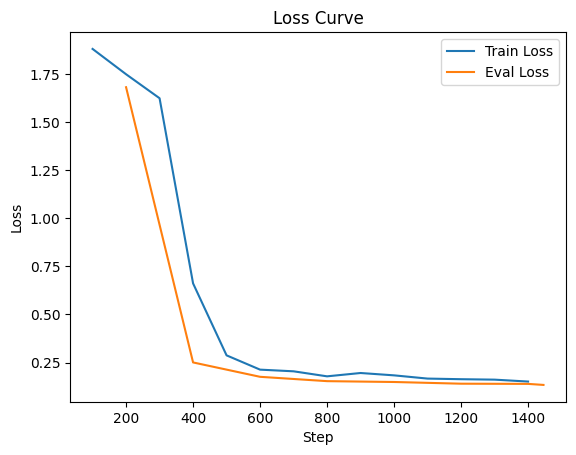

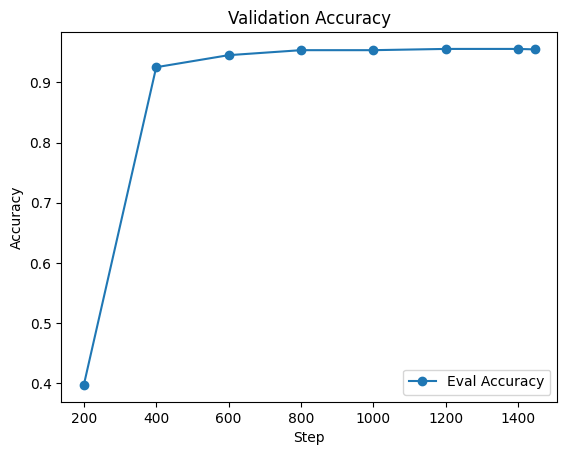

In [19]:
import matplotlib.pyplot as plt

logs = trainer.state.log_history

train_steps = [log["step"] for log in logs if "loss" in log]
train_loss = [log["loss"] for log in logs if "loss" in log]

eval_steps = [log["step"] for log in logs if "eval_loss" in log]
eval_loss = [log["eval_loss"] for log in logs if "eval_loss" in log]
eval_accuracy = [log["eval_accuracy"] for log in logs if "eval_accuracy" in log]

plt.figure()
plt.plot(train_steps, train_loss, label="Train Loss")
plt.plot(eval_steps, eval_loss, label="Eval Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.figure()
plt.plot(eval_steps, eval_accuracy, label="Eval Accuracy", marker='o')
plt.xlabel("Step")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.legend()
plt.show()


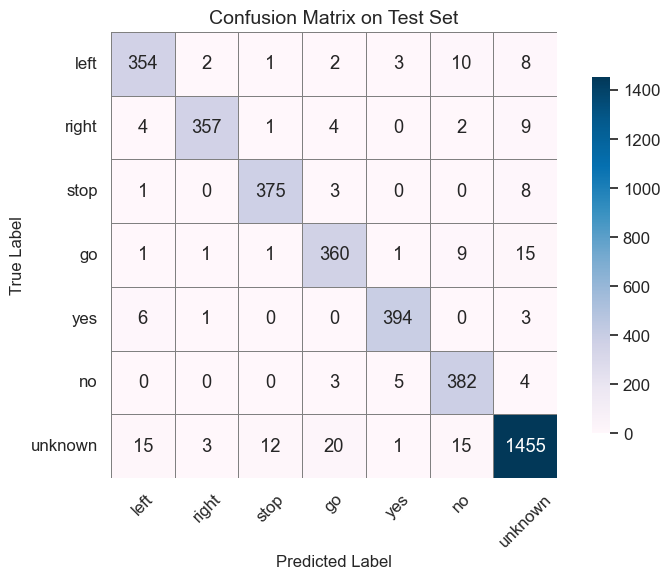

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 获取预测结果
predictions = trainer.predict(dataset["test"])
y_true = predictions.label_ids
y_pred = predictions.predictions.argmax(axis=-1)

# 计算混淆矩阵
cm = confusion_matrix(y_true, y_pred)
labels = list(TARGET_KEYWORDS.keys()) + ["unknown"]

# 创建美观的 heatmap
plt.figure(figsize=(8, 6))
sns.set(style="whitegrid", font_scale=1.1)

ax = sns.heatmap(cm, annot=True, fmt="d", cmap="PuBu", 
                 xticklabels=labels, yticklabels=labels, 
                 linewidths=0.5, linecolor='gray', square=True,
                 cbar_kws={'shrink': 0.8})

# 标签与标题
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)
ax.set_title("Confusion Matrix on Test Set", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


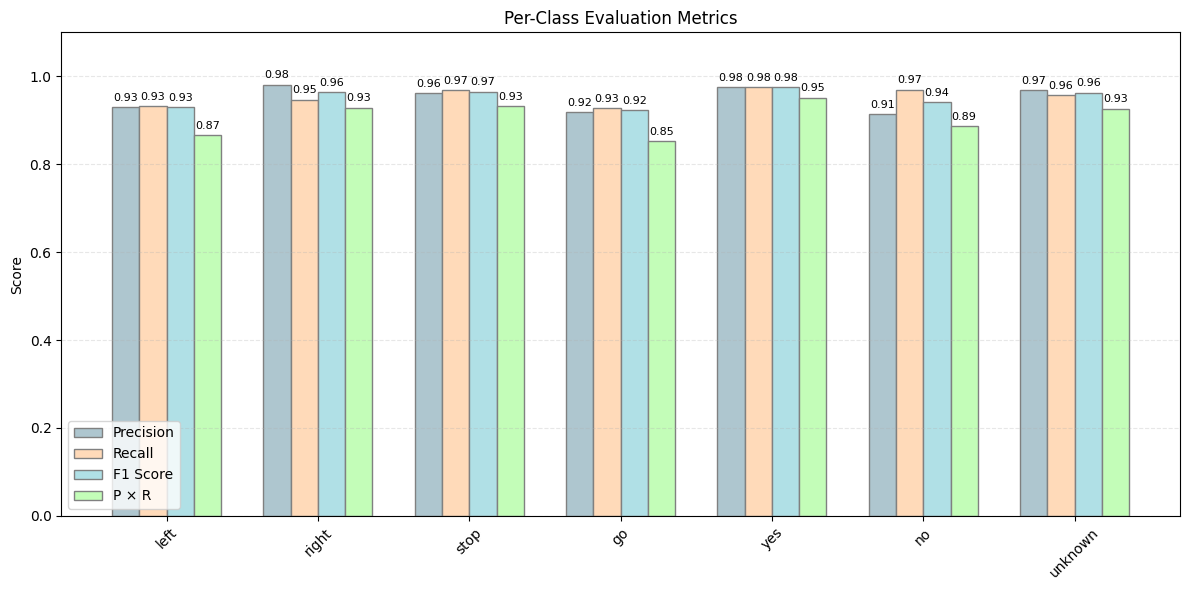

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# 提取指标
target_names = list(TARGET_KEYWORDS.keys()) + ["unknown"]
report = classification_report(y_true, y_pred, target_names=target_names, output_dict=True)

precision_scores = [report[label]["precision"] for label in target_names]
recall_scores = [report[label]["recall"] for label in target_names]
f1_scores = [report[label]["f1-score"] for label in target_names]
pr_scores = [p * r for p, r in zip(precision_scores, recall_scores)] 

# 所有指标
metrics = [precision_scores, recall_scores, f1_scores, pr_scores]
metric_names = ["Precision", "Recall", "F1 Score", "P × R"]

# 柔和颜色方案（pastel-like）
soft_colors = ["#AEC6CF", "#FFDAB9", "#B0E0E6", "#C3FDB8"]  # 蓝、橘、青、绿系柔和色

# 设置参数
x = np.arange(len(target_names))  # 类别位置
width = 0.18  # 柱宽

plt.figure(figsize=(12, 6))

for i, (metric, name, color) in enumerate(zip(metrics, metric_names, soft_colors)):
    bar = plt.bar(x + i * width - 1.5 * width, metric, width, label=name, color=color, edgecolor='gray')
    # 添加标注
    for rect in bar:
        height = rect.get_height()
        plt.text(rect.get_x() + rect.get_width() / 2, height + 0.01,
                 f"{height:.2f}", ha='center', va='bottom', fontsize=8)

# 美化坐标轴
plt.xticks(x, target_names, rotation=45)
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.title("Per-Class Evaluation Metrics")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()
